name: PriceNest AI

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load the dataset
df = pd.read_csv('imputation_done.csv')

In [4]:
latlog = pd.read_csv('latlong.csv')

In [5]:
latlog

,sector,coordinates
0,sector 1,"28.3663° N, 76.9456° E"
1,sector 2,"28.5095° N, 77.0320° E"
2,sector 3,"28.4909° N, 77.0176° E"
3,sector 4,"28.4738° N, 77.0107° E"
4,sector 5,"28.4794° N, 77.0176° E"
...,...,...
124,sector 113,"28.5287° N, 77.0233° E"
125,sector 114,"28.5334° N, 77.0118° E"
126,sector 115,"28.5385° N, 77.0061° E"
127,gwal pahari,"28.4484° N, 77.0210° E"


In [6]:
latlog['latitude'] = latlog['coordinates'].str.split(',').str.get(0).str.split('°').str.get(0).astype(float)
latlog['longitude'] = latlog['coordinates'].str.split(',').str.get(1).str.split('°').str.get(0).astype(float)


In [7]:
latlog.head()

,sector,coordinates,latitude,longitude
0,sector 1,"28.3663° N, 76.9456° E",28.3663,76.9456
1,sector 2,"28.5095° N, 77.0320° E",28.5095,77.0320
2,sector 3,"28.4909° N, 77.0176° E",28.4909,77.0176
3,sector 4,"28.4738° N, 77.0107° E",28.4738,77.0107
4,sector 5,"28.4794° N, 77.0176° E",28.4794,77.0176


In [8]:
latlog.drop(columns=['coordinates'], inplace=True)

In [9]:
new_df = df.merge(latlog,on='sector')

In [10]:
new_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio,latitude,longitude
0,flat,signature global park 4,sector 36,0.82,7586.0,1081.0,Super Built up area 1081(100.43 sq.m.)Carpet a...,3.0,2.0,2,...,0.0,0.0,0.0,0.0,0.0,0.0,8.0,360.333333,28.4160,76.9914
1,flat,smart world gems,sector 89,0.95,8597.0,1105.0,Carpet area: 1103 (102.47 sq.m.),2.0,2.0,2,...,1.0,1.0,0.0,0.0,0.0,0.0,38.0,552.500000,28.4253,76.9439
2,flat,bestech park view sanskruti,sector 92,1.60,8020.0,1995.0,Super Built up area 1995(185.34 sq.m.)Built Up...,3.0,4.0,3+,...,0.0,1.0,0.0,0.0,1.0,1.0,174.0,665.000000,28.4079,76.9153
3,flat,suncity avenue,sector 102,0.48,9023.0,532.0,Super Built up area 632(58.71 sq.m.)Carpet are...,2.0,2.0,1,...,0.0,0.0,1.0,0.0,0.0,0.0,159.0,266.000000,28.4750,76.9715
4,flat,paras quartier,gwal pahari,7.50,14019.0,5350.0,Super Built up area 5350(497.03 sq.m.),4.0,4.0,3+,...,0.0,1.0,0.0,1.0,1.0,1.0,49.0,1337.500000,28.4484,77.0210


In [11]:
group_df = new_df.groupby('sector')[['price', 'price_per_sqft','built_up_area','latitude', 'longitude']].mean()

In [11]:
#!pip install plotly

In [12]:
#!pip install --upgrade nbformat

In [12]:
group_df.head()

,price,price_per_sqft,built_up_area,latitude,longitude
sector,,,,,
gwal pahari,3.192222,9585.777778,3056.166667,28.4484,77.0210
manesar,0.962258,4608.064516,2027.367742,28.3515,76.9428
sector 1,1.860000,8249.833333,2327.833333,28.3663,76.9456
sector 10,2.092857,11866.571429,1908.857143,28.4537,77.0009
sector 102,1.696636,10603.822430,1556.130841,28.4750,76.9715


In [13]:
import plotly.express as px
fig = px.scatter_mapbox(group_df,lat='latitude',lon='longitude',color='price_per_sqft',size='built_up_area',
                        color_continuous_scale=px.colors.cyclical.IceFire,zoom=10,
                        mapbox_style="open-street-map",text=group_df.index) 
fig.show()

C:\Users\Hardik\AppData\Local\Temp\ipykernel_17620\4290137454.py:2: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(group_df,lat='latitude',lon='longitude',color='price_per_sqft',size='built_up_area',


In [15]:
new_df.to_csv('data_viz1.csv', index=False)

In [14]:
df1 = pd.read_csv('gurgaon_properties.csv')

In [15]:
df1.head()

,property_type,society,price,price_per_sqft,sector,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features
0,flat,maa bhagwati residency,0.45,5000.0,Krishna Colony,900.0,Carpet area: 900 (83.61 sq.m.),2,2,1,NaN,4.0,West,1 to 5 Year Old,"['Chintapurni Mandir', 'State bank ATM', 'Pear...","['3 Fan', '4 Light', '1 Wardrobe', 'No AC', 'N...","['Feng Shui / Vaastu Compliant', 'Security / F..."
1,flat,apna enclave,0.50,7692.0,Ashok Vihar,650.0,Carpet area: 650 (60.39 sq.m.),2,2,1,NaN,1.0,West,10+ Year Old,"['Chintapurni Mandir', 'Sheetla Mata Mandir', ...","['3 Wardrobe', '4 Fan', '1 Exhaust Fan', '1 Ge...","['Security / Fire Alarm', 'Maintenance Staff',..."
2,flat,tulsiani easy in homes,0.40,6722.0,Sohna,595.0,Carpet area: 595 (55.28 sq.m.),2,2,3,NaN,12.0,NaN,0 to 1 Year Old,"['Huda City Metro', 'Golf Course extn road', '...",NaN,"['Power Back-up', 'Feng Shui / Vaastu Complian..."
3,flat,smart world orchard,1.47,12250.0,Sector 61,1200.0,Carpet area: 1200 (111.48 sq.m.),2,2,2,study room,2.0,NaN,Dec 2023,"['Sector 55-56 Metro station', 'Bestech Centra...",NaN,"['Security / Fire Alarm', 'Private Garden / Te..."
4,flat,parkwood westend,0.70,5204.0,Sector 92,1345.0,Super Built up area 1345(124.95 sq.m.),2,2,3,study room,5.0,NaN,Under Construction,"['Yadav Clinic', 'Bangali Clinic', 'Dr. J. S. ...",[],NaN


In [16]:
merged = df1.merge(df, left_index=True, right_index=True)
print(merged.columns)

Index(['property_type_x', 'society_x', 'price_x', 'price_per_sqft_x',
       'sector_x', 'area_x', 'areaWithType_x', 'bedRoom_x', 'bathroom_x',
       'balcony_x', 'additionalRoom', 'floorNum_x', 'facing',
       'agePossession_x', 'nearbyLocations', 'furnishDetails', 'features',
       'property_type_y', 'society_y', 'sector_y', 'price_y',
       'price_per_sqft_y', 'area_y', 'areaWithType_y', 'bedRoom_y',
       'bathroom_y', 'balcony_y', 'floorNum_y', 'agePossession_y',
       'built_up_area', 'study room', 'servant room', 'store room',
       'pooja room', 'others', 'furnishing_type', 'luxury_score',
       'area_room_ratio'],
      dtype='object')


In [17]:
word_cloud = df1.merge(df,left_index=True,right_index=True)[['features','sector_y']]

In [18]:
word_cloud.head(1)

,features,sector_y
0,"['Feng Shui / Vaastu Compliant', 'Security / F...",sector 36


In [29]:
import pickle
with open('word_cloud_data.pkl', 'wb') as f:
    pickle.dump(word_cloud, f)

In [28]:
word_cloud[word_cloud['sector_y']=='sector 36']

,features,sector_y
0,"['Feng Shui / Vaastu Compliant', 'Security / F...",sector 36
60,"['Power Back-up', 'Feng Shui / Vaastu Complian...",sector 36
387,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...",sector 36
475,"['Feng Shui / Vaastu Compliant', 'Security / F...",sector 36
674,"['Intercom Facility', 'Lift(s)', 'Maintenance ...",sector 36
760,"['Centrally Air Conditioned', 'Water purifier'...",sector 36
866,"['Centrally Air Conditioned', 'Water purifier'...",sector 36
935,"['Centrally Air Conditioned', 'Water purifier'...",sector 36
944,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...",sector 36
1013,"['Security / Fire Alarm', 'Power Back-up', 'Fe...",sector 36


In [21]:
import ast
main = []
for item in word_cloud['features'].dropna().apply(ast.literal_eval):
    #this will convert the string representation of list to an actual list
    main.extend(item) 

In [26]:
!pip install wordcloud

  Obtaining dependency information for wordcloud from https://files.pythonhosted.org/packages/b1/6a/47d0d8c5ca74400750797ae8fd13f200204294e008e1235e51814e732b09/wordcloud-1.9.6-cp312-cp312-win_amd64.whl.metadata
  Using cached wordcloud-1.9.6-cp312-cp312-win_amd64.whl.metadata (3.5 kB)
Using cached wordcloud-1.9.6-cp312-cp312-win_amd64.whl (307 kB)



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
from wordcloud import WordCloud

In [22]:
feature_text = ' '.join(main)

In [29]:
import pickle
pickle.dump(feature_text, open('feature_text.pkl','wb'))

In [23]:
feature_text

'Feng Shui / Vaastu Compliant Security / Fire Alarm Lift(s) Water Storage Visitor Parking Security / Fire Alarm Maintenance Staff Water Storage Park Visitor Parking Power Back-up Feng Shui / Vaastu Compliant Intercom Facility Lift(s) Swimming Pool Park Fitness Centre / GYM Club house / Community Center Security / Fire Alarm Private Garden / Terrace Lift(s) Maintenance Staff False Ceiling Lighting Water Storage Visitor Parking Swimming Pool Natural Light Airy Rooms Fitness Centre / GYM Club house / Community Center Water softening plant Power Back-up Intercom Facility Lift(s) Swimming Pool Maintenance Staff Park Security Personnel Internet/wi-fi connectivity Fitness Centre / GYM Club house / Community Center Rain Water Harvesting Water softening plant Feng Shui / Vaastu Compliant Intercom Facility Lift(s) Maintenance Staff Swimming Pool Park Security Personnel Fitness Centre / GYM Club house / Community Center Rain Water Harvesting Security / Fire Alarm Intercom Facility Lift(s) Mainten

In [35]:
fig = px.scatter(df,x='built_up_area',y='price',title='Area vs Price',color='bedRoom')
fig.show()

In [ ]:
fig = px.pie(df,names='bedRoom',title='Total Bill Amount by day')
fig.show()

In [38]:
temp_df = df[df['bedRoom'] <= 4]
#create side by side boxplots
fig = px.box(temp_df,x='bedRoom',y='price',title='BHK Price Range')
fig.show()


C:\Users\Hardik\AppData\Local\Temp\ipykernel_17620\2505783054.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['property_type']=='house']['price'],label='house')
C:\Users\Hardik\AppData\Local\Temp\ipykernel_17620\2505783054.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['prop

<Axes: xlabel='price', ylabel='Density'>

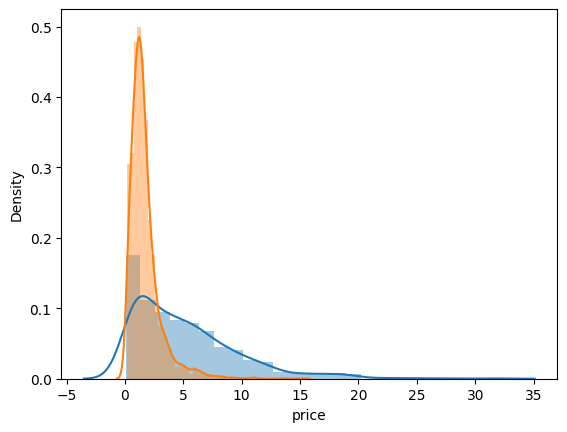

In [39]:
sns.distplot(df[df['property_type']=='house']['price'],label='house')
sns.distplot(df[df['property_type']=='flat']['price'],label='flat')
